In [ ]:
import pandas as pd
import numpy as np
import pickle
import re
import json
from huggingface_hub import snapshot_download

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tueplots import bundles
bundles.icml2024()

def visualize_response_matrix(results, value, filename):
    # Extract the scenarios labels in the order of the columns
    scenario_values = results.columns.get_level_values("scenario")

    # Identify the boundaries where the scenario changes
    boundaries = []
    for i in range(1, len(scenario_values)):
        if scenario_values[i] != scenario_values[i - 1]:
            boundaries.append(i - 0.5)  # using 0.5 to place the line between columns

    # visualize the results with a matrix red is 0, white is -1 and blue is 1
    cmap = mcolors.ListedColormap(["white", "red", "blue"])
    bounds = [-1.5, -0.5, 0.5, 1.5]  # Define boundaries for the three categories
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Calculate midpoints for each scenario label
    scenarios_list = list(scenario_values)
    scenario_names = []
    scenario_midpoints = []
    current_scenario = scenarios_list[0]
    start_index = 0
    for i, grp in enumerate(scenarios_list):
        if grp != current_scenario:
            midpoint = (start_index + i - 1) / 2.0
            scenario_names.append(current_scenario)
            scenario_midpoints.append(midpoint)
            current_scenario = grp
            start_index = i
            
    # Add the last scenario
    midpoint = (start_index + len(scenarios_list) - 1) / 2.0
    scenario_names.append(current_scenario)
    scenario_midpoints.append(midpoint)

    # Define the minimum spacing between labels (e.g., 500 units)
    min_spacing = 100
    last_label_pos = -float("inf")
    # Plot the matrix
    with plt.rc_context(bundles.icml2024(usetex=True, family="serif")):
        fig, ax = plt.subplots(figsize=(20, 10))
        cax = ax.matshow(value, aspect="auto", cmap=cmap, norm=norm)

        # Add vertical lines at each boundary
        for b in boundaries:
            ax.axvline(x=b, color="black", linewidth=0.25, linestyle="--", alpha=0.5)
        
        # Add scenario labels above the matrix, but only if they're at least 500 apart
        for name, pos in zip(scenario_names, scenario_midpoints):
            if pos - last_label_pos >= min_spacing:
                # name = eval(name)
                # name = "/".join(name) 
                ax.text(pos, -5, name, ha='center', va='easy', rotation=90, fontsize=3)
                last_label_pos = pos

        # add model labels
        ax.set_yticks(range(len(results.index)))
        ax.set_yticklabels(results.index, fontsize=3)

        # Add colorbar
        cbar = plt.colorbar(cax)
        cbar.set_ticks([-1, 0, 1])
        cbar.set_ticklabels(["-1", "0", "1"])
        plt.savefig(f"{filename}.png", dpi=600, bbox_inches="tight")
        plt.close()

# read long table
with open(f"../data/gather_helm_data/responses.pkl", "rb") as f:
    results_full = pickle.load(f)

# extract GSM8K scenario from HELM Lite
results_full = results_full.sample(frac=1).reset_index(drop=True)
results_full = results_full.query('benchmark == "lite" and scenario == "gsm"')

# keep useful columns, drop nan rows
results = results_full[["request.model", "request.prompt", "references", "scenario", "dicho_score"]]
results = results.dropna(subset=["request.model", "request.prompt", "references", "scenario", "dicho_score"])

# assert only binary responses
results["dicho_score"] = results["dicho_score"].astype(bool)
assert results["dicho_score"].isin([0, 1]).all()

# drop duplicate rows
results = results.drop_duplicates(subset=["request.model", "request.prompt", "references", "scenario"], keep='first')
print(f"non-duplicate percentage:{results.shape[0]/results_full.shape[0]}")

# pivot to turn long table into matrix
results = results.pivot(index="request.model", columns=["request.prompt",  "references", "scenario"], values="dicho_score")

# sort the columns by scenario
results = results.sort_index(axis=1, level="scenario")

# nan -> -1 -> np.nan
results = results.fillna(-1).astype(int)
results = results.replace(-1, np.nan)

# Compute the overall average for each scenario manually
scenario_means = {}
for scenario in results.columns.get_level_values("scenario").unique():
    mask = results.columns.get_level_values("scenario") == scenario
    values = results.loc[:, mask].values  # all values for this scenario
    scenario_means[scenario] = np.nanmean(values)

# Sort the scenario by their average score
sorted_scenarios = sorted(scenario_means, key=scenario_means.get)

# Create a mapping from scenario to its sort order
scenario_order = {scenario: order for order, scenario in enumerate(sorted_scenarios)}

# Reorder the columns based on the new scenario order using the key parameter
results = results.sort_index(axis=1, level="scenario", key=lambda x: x.map(scenario_order))

# Compute the overall average for each row (ignoring NaNs)
row_means = results.mean(axis=1)

# Sort the rows by these computed averages (lowest to highest)
results = results.loc[row_means.sort_values().index]

# np.nan -> -1
results = results.replace(np.nan, -1)

# due to some data-preprocessing issue, the response_matrix_5000cols.png is block diagnol. We will fix this later.
# Currently, we simply take the last 1000 columns
# visualize_response_matrix(results, results, "response_matrix_5000cols")

# take the last 1000 columns, drop rows that is all nan
# now there is no missing data
results = results.iloc[:, 4000:]
results = results[~(results == -1).all(axis=1)]

# delete columns that only have 0 or only have 1
results = results.loc[:, (results != 0).any()]
results = results.loc[:, (results != 1).any()]
# visualize_response_matrix(results, results, "response_matrix_1000cols")
print(results.shape)

# this huggingface dataset contains the request.prompt and their corresponding difficulty z
dataset_path = snapshot_download(
    repo_id = "stair-lab/reeval-difficulty-for-helm",
    repo_type = "dataset",
)
dataset = pd.read_parquet(f"{dataset_path}/data/gsm-00000-of-00001.parquet")
prompt_to_z = dict(zip(dataset["request.prompt"], dataset["z"]))
    
# add a new column key to matrix: z, delete the column key: scenario
new_columns = []
for col in results.columns:
    # In our current MultiIndex, level 0 is "request.prompt", level 1 is "references", level 2 is "scenario"
    prompt, ref = col[0], col[1]
    z = prompt_to_z.get(prompt, np.nan)
    new_columns.append((prompt, ref, z))
results.columns = pd.MultiIndex.from_tuples(new_columns, names=["request.prompt", "references", "z"])

mkdir -p failed for path /dfs/user/sttruong/.cache/matplotlib: [Errno 13] Permission denied: '/dfs/user/sttruong'
Matplotlib created a temporary cache directory at /tmp/user/21130/matplotlib-sl2qivne because there was an issue with the default path (/dfs/user/sttruong/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


non-duplicate percentage:1.0
(70, 997)


Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

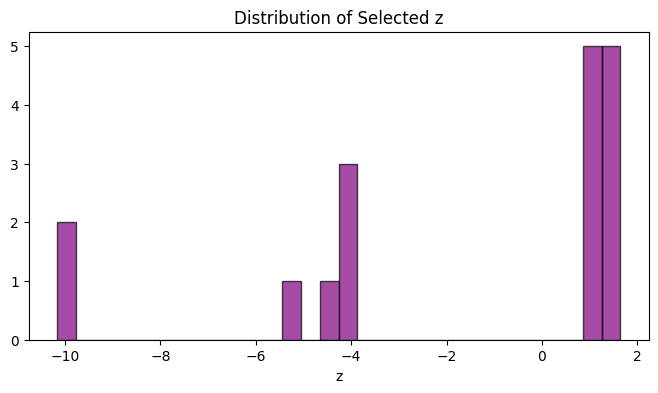

In [ ]:
num_easy = 10
num_hard = 7
total_item = num_easy + num_hard

# Step 1: Extract z as NumPy array
z_array = results.columns.get_level_values("z").astype(float).to_numpy()

# Step 2: Sort indices by z
sorted_indices = np.argsort(z_array)

# Step 3: Get easy and hard num_easy_hard indices
easy_idx = sorted_indices[-num_easy:]
hard_idx = sorted_indices[:num_hard]

# Step 4: Get MultiIndex columns
easy_cols = results.columns[easy_idx]
hard_cols = results.columns[hard_idx]

# Step 5: Combine and extract sub_df
selected_columns = easy_cols.append(hard_cols)
sub_df = results[selected_columns]

# Step 6: Rename columns
easy_names = [f"e{i+1}" for i in range(num_easy)]
difficult_names = [f"d{i+1}" for i in range(num_hard)]
diffeasy = easy_names + difficult_names
new_columns = []
for i, col in enumerate(sub_df.columns):
    new_columns.append((col[0], col[1], col[2], diffeasy[i]))
sub_df.columns = pd.MultiIndex.from_tuples(new_columns, names=["request.prompt", "references", "z", "diffeasy"])

# Save diffeasy_to_z to JSON file
diffeasy_to_z = {}
for col in sub_df.columns:
    z = col[2]
    diffeasy = col[3]
    diffeasy_to_z[diffeasy] = z
with open(f"diffeasy_to_z_{total_item}.json", "w") as f:
    json.dump(diffeasy_to_z, f, indent=4)
    
# write the item content to a txt
with open(f"item_content_{total_item}.txt", "w") as f:
    for col in sub_df.columns:
        prompt = col[0]
        ref = col[1]
        z = col[2]
        diffeasy = col[3]
        # extract reference content
        match = re.search(r'"text":\s*"([^"]+)"', ref)
        ref = match.group(1)
        f.write(f"###{diffeasy}, difficulty: {z}\n###prompt: {prompt}\n###reference: {ref}\n\n\n\n\n")

# save response matrix to csv
sub_df.columns = sub_df.columns.get_level_values("diffeasy")
sub_df.index.name = None
sub_df.to_csv(f"gsm_hard_easy_{total_item}.csv", index=False)

# Plot selected z distribution
selected_z_values = np.concatenate([z_array[hard_idx], z_array[easy_idx]])
plt.figure(figsize=(8, 4))
plt.hist(selected_z_values, bins=30, alpha=0.7, color='purple', edgecolor='black')
plt.title("Distribution of Selected z")
plt.xlabel("z")
plt.savefig(f"selected_z_distribution_{total_item}.png", dpi=300, bbox_inches='tight')